In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler # <--- Added this

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

train_path = "../data/processed/tabular/train_data.csv"
test_path = "../data/processed/tabular/test_data.csv"

Using Device: cpu


In [2]:
# Initialize a global scaler for the target variable
target_scaler = MinMaxScaler()

# 1. Fit the scaler on the TRAINING data first (Standard Practice)
train_temp = pd.read_csv(train_path)
target_scaler.fit(train_temp[['energy_consumption_kwh']])

class SmartCityDataset(Dataset):
    def __init__(self, csv_file, scaler=None):
        self.data = pd.read_csv(csv_file)
        self.scaler = scaler
        
        self.tab_cols = ['median_income', 'population_density', 'avg_building_age', 'market_volatility']
        self.target_col = 'energy_consumption_kwh'
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # 1. Image
        img_path = row['file_path']
        image = np.load(img_path).astype(np.float32)
        image = np.transpose(image, (2, 0, 1))
        image = image[:3, :, :] # Keep only RGB
        
        # 2. Tabular
        tabular = row[self.tab_cols].values.astype(np.float32)
        
        # 3. Target (Apply Scaling Here)
        raw_target = row[self.target_col]
        if self.scaler:
            # Transform returns a 2D array, we need the scalar value
            target_scaled = self.scaler.transform([[raw_target]])[0][0]
        else:
            target_scaled = raw_target
            
        return {
            'image': torch.tensor(image),
            'tabular': torch.tensor(tabular),
            'target': torch.tensor(target_scaled, dtype=torch.float32)
        }

# Create DataLoaders with Scaling
train_dataset = SmartCityDataset(train_path, scaler=target_scaler)
test_dataset = SmartCityDataset(test_path, scaler=target_scaler)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Data Loaded with Target Scaling.")

Data Loaded with Target Scaling.


In [ ]:
class SustainabilityModel(nn.Module):
    def __init__(self):
        super(SustainabilityModel, self).__init__()
        
        # 1. Image Branch (ResNet-18)
        self.cnn = models.resnet18(pretrained=True)
        # Remove the final classification layer
        self.cnn.fc = nn.Identity() 
        # ResNet18 output is 512 dimensions
        
        # 2. Tabular Branch
        self.tab_layer = nn.Sequential(
            nn.Linear(4, 16), # 4 input features
            nn.ReLU()
        )
        
        # 3. Fusion Layer (Concatenate Image + Tabular)
        # Input = 512 (Image) + 16 (Tabular) = 528
        self.fusion = nn.Sequential(
            nn.Linear(512 + 16, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # Single output: Energy Consumption
        )
        
    def forward(self, image, tabular):
        # Pass image through CNN
        x_img = self.cnn(image)
        
        # Pass tabular through simple MLP
        x_tab = self.tab_layer(tabular)
        
        # Concatenate features
        x_combined = torch.cat((x_img, x_tab), dim=1)
        
        # Final Prediction
        prediction = self.fusion(x_combined)
        return prediction.squeeze()

model = SustainabilityModel().to(device)
print("Hybrid Model Architecture Initialized")

In [ ]:
# Re-initialize model to reset weights
model = SustainabilityModel().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Lower learning rate slightly
epochs = 50 

train_losses = []

print("Starting Training (50 Epochs)...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch in train_loader:
        imgs = batch['image'].to(device)
        tabs = batch['tabular'].to(device)
        targets = batch['target'].to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs, tabs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}")

print("Training Complete!")

# Plot Loss Curve
plt.plot(train_losses)
plt.title("Training Loss (Scaled)")
plt.show()

c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warni

R² Score: 0.0934


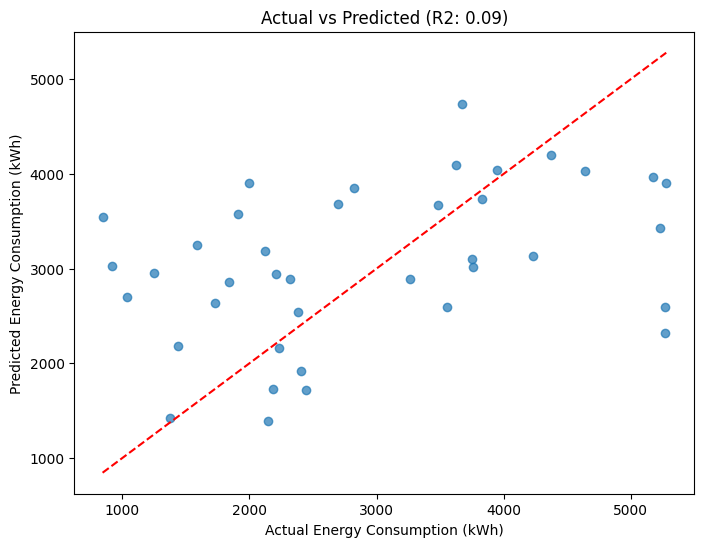

In [5]:
model.eval()
predictions_scaled = []
actuals_scaled = []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch['image'].to(device)
        tabs = batch['tabular'].to(device)
        targets = batch['target'].to(device)
        
        outputs = model(imgs, tabs)
        
        predictions_scaled.extend(outputs.cpu().numpy())
        actuals_scaled.extend(targets.cpu().numpy())

# Inverse Transform to get real kWh values
predictions = target_scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1))
actuals = target_scaler.inverse_transform(np.array(actuals_scaled).reshape(-1, 1))

# Metrics
r2 = r2_score(actuals, predictions)
print(f"R² Score: {r2:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, alpha=0.7)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title(f"Actual vs Predicted (R2: {r2:.2f})")
plt.show()